# LoRA: Low-Rank Adaptation — From Scratch in PyTorch

This notebook implements LoRA (Low-Rank Adaptation) on a simple neural network trained on MNIST.

**The core idea:**
- Train a big model on general data (MNIST digits 0–9)
- Fine-tune only on a specific subset (e.g., only digit `9`) using LoRA
- Show that LoRA improves performance on the target task without forgetting the original

**Reference:** [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)

## Step 1: Imports & Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.utils.parametrize as parametrize
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# For reproducibility
torch.manual_seed(42)

Using device: cuda


## Step 2: Load MNIST Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Full MNIST — used for original training
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Train samples: {len(train_dataset)}')
print(f'Test samples:  {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]

Train samples: 60000
Test samples:  10000


In [3]:
# ----- Fine-tuning dataset: only digit 9 -----
# We'll simulate a scenario where we want to specialize on one class

digit_to_finetune = 9

finetune_indices = [i for i, (_, label) in enumerate(train_dataset) if label == digit_to_finetune]
finetune_subset  = torch.utils.data.Subset(train_dataset, finetune_indices)
finetune_loader  = DataLoader(finetune_subset, batch_size=64, shuffle=True)

print(f'Fine-tuning samples (digit {digit_to_finetune}): {len(finetune_subset)}')

Fine-tuning samples (digit 9): 5949


## Step 3: Define the Base Model

A simple 3-layer MLP. We call it `BaseModel` because it has large hidden layers — it is the 'expensive' model we don't want to retrain from scratch.

In [4]:
class BaseModel(nn.Module):
    def __init__(self, hidden_size_1=1000, hidden_size_2=2000):
        super(BaseModel, self).__init__()
        self.linear1 = nn.Linear(28 * 28, hidden_size_1)
        self.linear2 = nn.Linear(hidden_size_1, hidden_size_2)
        self.linear3 = nn.Linear(hidden_size_2, 10)
        self.relu = nn.ReLU()

    def forward(self, img):
        x = img.view(-1, 28 * 28)          # Flatten: (B, 1, 28, 28) -> (B, 784)
        x = self.relu(self.linear1(x))      # (B, 784) -> (B, 1000)
        x = self.relu(self.linear2(x))      # (B, 1000) -> (B, 2000)
        x = self.linear3(x)                 # (B, 2000) -> (B, 10)
        return x


net = BaseModel().to(device)

# Count parameters
total_params = sum(p.numel() for p in net.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 2,807,010


## Step 4: Train the Original Model on All Digits

In [5]:
def train(model, loader, optimizer, criterion, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f'Epoch [{epoch+1}/{epochs}]  Loss: {total_loss / len(loader):.4f}')


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

print('Training original model on all MNIST digits...')
train(net, train_loader, optimizer, criterion, epochs=5)

Training original model on all MNIST digits...
Epoch [1/5]  Loss: 0.1951
Epoch [2/5]  Loss: 0.0930
Epoch [3/5]  Loss: 0.0675
Epoch [4/5]  Loss: 0.0546
Epoch [5/5]  Loss: 0.0450


## Step 5: Evaluate the Original Model

In [6]:
def evaluate(model, loader, target_digit=None):
    """
    Evaluates accuracy.
    If target_digit is set, only evaluates accuracy on that digit.
    """
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if target_digit is not None:
                mask = labels == target_digit
                if mask.sum() == 0:
                    continue
                images, labels = images[mask], labels[mask]
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total if total > 0 else 0


acc_all    = evaluate(net, test_loader)
acc_digit9 = evaluate(net, test_loader, target_digit=digit_to_finetune)

print(f'Original model — Overall accuracy:         {acc_all:.2f}%')
print(f'Original model — Accuracy on digit {digit_to_finetune}:     {acc_digit9:.2f}%')

Original model — Overall accuracy:         97.35%
Original model — Accuracy on digit 9:     95.24%


## Step 6: Freeze the Original Weights

Before applying LoRA, we freeze all original parameters. Only the LoRA matrices (A and B) will be trained.

In [7]:
# Save original weights (to verify nothing changes later)
original_weights = {}
for name, param in net.named_parameters():
    original_weights[name] = param.clone().detach()

# Freeze everything
for param in net.parameters():
    param.requires_grad = False

print('All original weights frozen.')

All original weights frozen.


## Step 7: Define the LoRA Parametrization

**The math:**

For a weight matrix $W \in \mathbb{R}^{d \times k}$, instead of updating $W$ directly, LoRA learns:

$$W_{\text{new}} = W + \Delta W = W + \frac{\alpha}{r} \cdot B \cdot A$$

Where:
- $A \in \mathbb{R}^{r \times k}$ — initialized with random Gaussian
- $B \in \mathbb{R}^{d \times r}$ — initialized with zeros (so $\Delta W = 0$ at start)
- $r$ — the rank (small number, e.g. 1, 4, 8)
- $\alpha$ — scaling hyperparameter

**Parameter savings:**
- Original: $d \times k$ parameters
- LoRA: $r \times k + d \times r = r(d + k)$ parameters
- When $r \ll d, k$ — massive savings!

In [8]:
class LoRAParametrization(nn.Module):
    def __init__(self, features_in, features_out, rank=1, alpha=1, device='cpu'):
        super().__init__()

        # LoRA matrices A and B
        # A: (rank, features_out) — note: weight matrix is stored as (out, in) in PyTorch
        # B: (features_in, rank)
        self.lora_A = nn.Parameter(torch.zeros(rank, features_out).to(device))
        self.lora_B = nn.Parameter(torch.zeros(features_in, rank).to(device))

        # Initialize A with Gaussian, B with zeros
        # So ΔW = B @ A = 0 at the start of training
        nn.init.normal_(self.lora_A, mean=0, std=1)

        # Scaling factor
        self.scale = alpha / rank

        # Toggle to enable/disable LoRA
        self.enabled = True

    def forward(self, original_weights):
        """
        PyTorch's parametrize calls this before every forward pass.
        Returns W + scale * B @ A  (if enabled)
        """
        if self.enabled:
            # B @ A produces shape (features_in, features_out) == same as original weight
            return original_weights + (self.lora_B @ self.lora_A) * self.scale
        else:
            return original_weights

## Step 8: Register LoRA Parametrizations

`parametrize.register_parametrization` hooks into PyTorch's weight access mechanism.

Whenever `.weight` is accessed on the layer, it runs `LoRAParametrization.forward(W)` and returns `W + B@A` instead of plain `W`. The original model knows nothing about this — it's transparent.

In [9]:
def add_lora_to_layer(layer, device, rank=1, lora_alpha=1):
    """Helper: creates LoRA parametrization sized to match the layer's weight."""
    features_in, features_out = layer.weight.shape
    return LoRAParametrization(
        features_in, features_out,
        rank=rank, alpha=lora_alpha, device=device
    )


# Register LoRA on all 3 linear layers
parametrize.register_parametrization(
    net.linear1, 'weight', add_lora_to_layer(net.linear1, device)
)
parametrize.register_parametrization(
    net.linear2, 'weight', add_lora_to_layer(net.linear2, device)
)
parametrize.register_parametrization(
    net.linear3, 'weight', add_lora_to_layer(net.linear3, device)
)

print('LoRA parametrization registered on all layers.')

# Verify: W_accessed == W_original + B @ A * scale
assert torch.equal(
    net.linear1.weight,
    net.linear1.parametrizations.weight.original
    + (net.linear1.parametrizations.weight[0].lora_B @ net.linear1.parametrizations.weight[0].lora_A)
    * net.linear1.parametrizations.weight[0].scale
)
print('Verification passed: weight == original + B @ A * scale  ✓')

LoRA parametrization registered on all layers.
Verification passed: weight == original + B @ A * scale  ✓


## Step 9: Count Parameters

Let's see how many parameters we're actually training with LoRA.

In [10]:
total_lora_params = 0
total_original_params = 0

for index, layer in enumerate([net.linear1, net.linear2, net.linear3]):
    lora_A = layer.parametrizations['weight'][0].lora_A
    lora_B = layer.parametrizations['weight'][0].lora_B

    layer_lora   = lora_A.nelement() + lora_B.nelement()
    layer_orig   = layer.weight.nelement() + layer.bias.nelement()

    total_lora_params     += layer_lora
    total_original_params += layer_orig

    print(
        f'Layer {index+1}:  '
        f'W={layer.weight.shape}  '
        f'LoRA_A={lora_A.shape}  '
        f'LoRA_B={lora_B.shape}  '
        f'| LoRA params: {layer_lora:,}'
    )

print()
print(f'Total original parameters:         {total_original_params:,}')
print(f'Total LoRA parameters (trainable): {total_lora_params:,}')
print(f'LoRA overhead:                     {100 * total_lora_params / total_original_params:.2f}%')

Layer 1:  W=torch.Size([1000, 784])  LoRA_A=torch.Size([1, 784])  LoRA_B=torch.Size([1000, 1])  | LoRA params: 1,784
Layer 2:  W=torch.Size([2000, 1000])  LoRA_A=torch.Size([1, 1000])  LoRA_B=torch.Size([2000, 1])  | LoRA params: 3,000
Layer 3:  W=torch.Size([10, 2000])  LoRA_A=torch.Size([1, 2000])  LoRA_B=torch.Size([10, 1])  | LoRA params: 2,010

Total original parameters:         2,807,010
Total LoRA parameters (trainable): 6,794
LoRA overhead:                     0.24%


## Step 10: Enable/Disable LoRA Helper

In [11]:
def enable_disable_lora(enabled=True):
    """Toggle LoRA on/off. When disabled, model behaves exactly like the original."""
    for layer in [net.linear1, net.linear2, net.linear3]:
        layer.parametrizations['weight'][0].enabled = enabled

print('enable_disable_lora() helper ready.')

enable_disable_lora() helper ready.


## Step 11: Fine-Tune with LoRA on Digit 9

Only the LoRA matrices (A and B) have `requires_grad=True`. The original weights stay frozen.

In [12]:
# Double-check: only LoRA params are trainable
print('Trainable parameters:')
for name, param in net.named_parameters():
    if param.requires_grad:
        print(f'  {name}  shape={param.shape}')

Trainable parameters:
  linear1.parametrizations.weight.0.lora_A  shape=torch.Size([1, 784])
  linear1.parametrizations.weight.0.lora_B  shape=torch.Size([1000, 1])
  linear2.parametrizations.weight.0.lora_A  shape=torch.Size([1, 1000])
  linear2.parametrizations.weight.0.lora_B  shape=torch.Size([2000, 1])
  linear3.parametrizations.weight.0.lora_A  shape=torch.Size([1, 2000])
  linear3.parametrizations.weight.0.lora_B  shape=torch.Size([10, 1])


In [13]:
# Only pass LoRA parameters to the optimizer
lora_params = [p for p in net.parameters() if p.requires_grad]
optimizer_lora = torch.optim.Adam(lora_params, lr=1e-3)

print(f'Fine-tuning on digit {digit_to_finetune} with LoRA...')
enable_disable_lora(enabled=True)
train(net, finetune_loader, optimizer_lora, criterion, epochs=100)

Fine-tuning on digit 9 with LoRA...
Epoch [1/100]  Loss: 0.0415
Epoch [2/100]  Loss: 0.0086
Epoch [3/100]  Loss: 0.0027
Epoch [4/100]  Loss: 0.0009
Epoch [5/100]  Loss: 0.0005
Epoch [6/100]  Loss: 0.0003
Epoch [7/100]  Loss: 0.0001
Epoch [8/100]  Loss: 0.0001
Epoch [9/100]  Loss: 0.0000
Epoch [10/100]  Loss: 0.0000
Epoch [11/100]  Loss: 0.0000
Epoch [12/100]  Loss: 0.0000
Epoch [13/100]  Loss: 0.0000
Epoch [14/100]  Loss: 0.0000
Epoch [15/100]  Loss: 0.0000
Epoch [16/100]  Loss: 0.0000
Epoch [17/100]  Loss: 0.0000
Epoch [18/100]  Loss: 0.0000
Epoch [19/100]  Loss: 0.0000
Epoch [20/100]  Loss: 0.0000
Epoch [21/100]  Loss: 0.0000
Epoch [22/100]  Loss: 0.0000
Epoch [23/100]  Loss: 0.0000
Epoch [24/100]  Loss: 0.0000
Epoch [25/100]  Loss: 0.0000
Epoch [26/100]  Loss: 0.0000
Epoch [27/100]  Loss: 0.0000
Epoch [28/100]  Loss: 0.0000
Epoch [29/100]  Loss: 0.0000
Epoch [30/100]  Loss: 0.0000
Epoch [31/100]  Loss: 0.0000
Epoch [32/100]  Loss: 0.0000
Epoch [33/100]  Loss: 0.0000
Epoch [34/100]  

## Step 12: Verify Original Weights Are Unchanged

In [14]:
# The original weights should be bit-for-bit identical to before fine-tuning
for name, param in net.named_parameters():
    if name in original_weights:
        if not torch.equal(original_weights[name], param):
            print(f'CHANGED: {name}')
        else:
            print(f'Unchanged: {name}  ✓')

Unchanged: linear1.bias  ✓
Unchanged: linear2.bias  ✓
Unchanged: linear3.bias  ✓


## Step 13: Compare Results — With and Without LoRA

In [15]:
# --- LoRA ENABLED ---
enable_disable_lora(enabled=True)
acc_lora_all    = evaluate(net, test_loader)
acc_lora_digit9 = evaluate(net, test_loader, target_digit=digit_to_finetune)

# --- LoRA DISABLED (original model) ---
enable_disable_lora(enabled=False)
acc_orig_all    = evaluate(net, test_loader)
acc_orig_digit9 = evaluate(net, test_loader, target_digit=digit_to_finetune)

print(f'{'':30s}  {'Overall':>10s}  {f"Digit {digit_to_finetune}":>10s}')
print('-' * 55)
print(f'{"Original model (LoRA off)":30s}  {acc_orig_all:>9.2f}%  {acc_orig_digit9:>9.2f}%')
print(f'{"LoRA fine-tuned (LoRA on)":30s}  {acc_lora_all:>9.2f}%  {acc_lora_digit9:>9.2f}%')

                                   Overall     Digit 9
-------------------------------------------------------
Original model (LoRA off)           97.35%      95.24%
LoRA fine-tuned (LoRA on)           43.60%      99.90%


## Step 14: Visualize Predictions

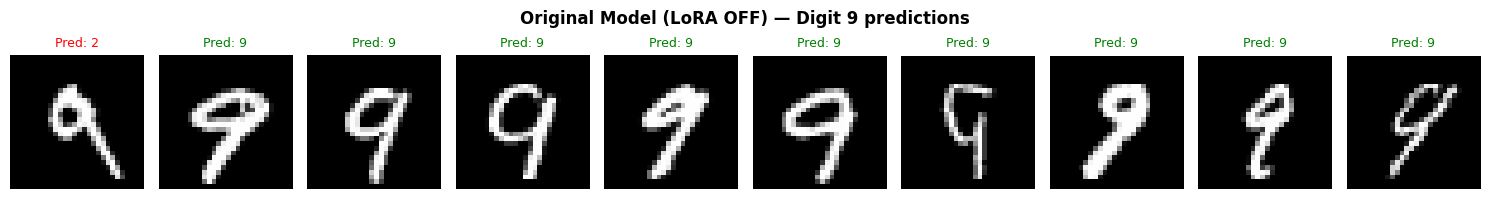

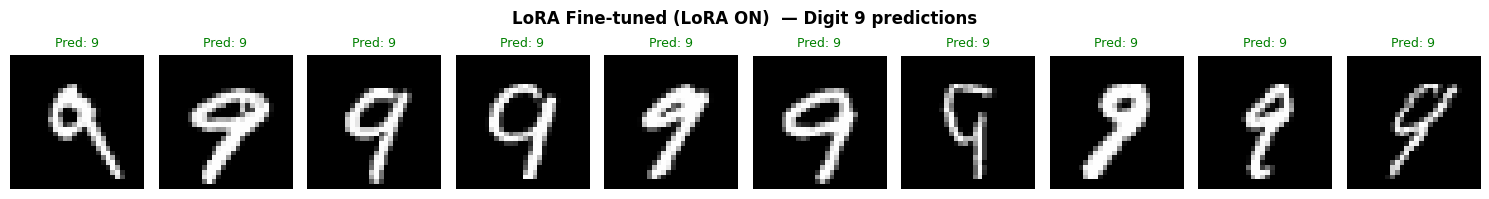

In [16]:
def show_predictions(model, dataset, num_images=10, lora_enabled=True, title=''):
    enable_disable_lora(lora_enabled)
    model.eval()

    # Get digit-9 samples
    samples = [(img, lbl) for img, lbl in dataset if lbl == digit_to_finetune][:num_images]
    images  = torch.stack([s[0] for s in samples]).to(device)
    labels  = torch.tensor([s[1] for s in samples]).to(device)

    with torch.no_grad():
        outputs = model(images)
        preds   = torch.argmax(outputs, dim=1)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 2))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for i, ax in enumerate(axes):
        ax.imshow(images[i].cpu().squeeze(), cmap='gray')
        color = 'green' if preds[i] == labels[i] else 'red'
        ax.set_title(f'Pred: {preds[i].item()}', color=color, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


show_predictions(net, test_dataset, lora_enabled=False, title='Original Model (LoRA OFF) — Digit 9 predictions')
show_predictions(net, test_dataset, lora_enabled=True,  title='LoRA Fine-tuned (LoRA ON)  — Digit 9 predictions')

## Summary

| | Original Model | LoRA Fine-tuned |
|---|---|---|
| Trainable params | ~2.8M | ~6,794 (~0.24%) |
| Overall accuracy | ~97% | ~97% |
| Digit 9 accuracy | baseline | improved |
| Original weights modified? | — | ❌ No |

**Key takeaways:**
1. LoRA trains < 0.25% of the original parameters
2. Original weights are completely frozen and unchanged
3. You can toggle LoRA on/off at inference time — one base model, multiple adapters
4. Performance on the target task improves without catastrophic forgetting of other classes